In [ ]:
# 01_data_acquisition_preparation.ipynb

##**Importing all necessary libraries**

In [ ]:


# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import os

##**Setting the  visualization style**


In [ ]:
# Setting the  visualization style

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

# Creating directories for data if they don't exist
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

##**Loading the Data**

In [ ]:

from google.colab import files
uploaded = files.upload()

Saving Year 2010-2011.csv to Year 2010-2011.csv


In [ ]:
import chardet

# Open the file in binary read mode ('rb')
with open('Year 2010-2011.csv', 'rb') as rawdata:
    # Detect the encoding using chardet
    result = chardet.detect(rawdata.read(100000))

# Print the detected encoding
print(result)

# If chardet detects 'ascii', try 'ISO-8859-1' or 'utf-8' instead
if result['encoding'] == 'ascii':
    try:
        # Try 'ISO-8859-1' first
        df = pd.read_csv('Year 2010-2011.csv', encoding='ISO-8859-1')
    except UnicodeDecodeError:
        # If 'ISO-8859-1' fails, try 'utf-8'
        df = pd.read_csv('Year 2010-2011.csv', encoding='utf-8')
else:
    # If chardet detects a different encoding, use that
    df = pd.read_csv('Year 2010-2011.csv', encoding=result['encoding'])

{'encoding': 'ascii', 'confidence': 1.0, 'language': ''}


##**Reading directly from the downloaded content**


In [ ]:
# Read directly from the downloaded content

import requests
import io
from zipfile import ZipFile
import pandas as pd

# df = pd.read_csv(io.BytesIO('Year 2010-2011.csv'))
# df=pd.read_csv('Year 2010-2011.csv')
print("Data loaded successfully.")

# Initial exploration
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
display(df.dtypes)

print("\nSummary statistics:")
display(df.describe())

print("\nMissing values:")
display(df.isnull().sum())

Data loaded successfully.
Dataset shape: (541910, 8)

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.00,United Kingdom



Data types:


,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
Price,float64
Customer ID,float64
Country,object



Summary statistics:


,Quantity,Price,Customer ID
count,541910.00,541910.00,406830.00
mean,9.55,4.61,15287.68
std,218.08,96.76,1713.60
min,-80995.00,-11062.06,12346.00
25%,1.00,1.25,13953.00
50%,3.00,2.08,15152.00
75%,10.00,4.13,16791.00
max,80995.00,38970.00,18287.00



Missing values:


,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0


##**Data cleaning**

In [ ]:
# Data cleaning
print("\nCleaning data...")

# 1. Convert invoice date to datetime if not already
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 2. Extract invoice date components
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDay'] = df['InvoiceDate'].dt.day
df['InvoiceDayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['InvoiceHour'] = df['InvoiceDate'].dt.hour

# 3. Create TotalAmount column
df['TotalAmount'] = df['Quantity'] * df['Price']

# 4. Filter out records with missing Customer ID
print(f"Records before filtering missing Customer ID: {len(df)}")
df_with_customerid = df.dropna(subset=['Customer ID'])
print(f"Records after filtering missing Customer ID: {len(df_with_customerid)}")

# 5. Convert Customer ID to string type
df_with_customerid['Customer ID'] = df_with_customerid['Customer ID'].astype(str)

# 6. Filter out cancelled orders (negative quantities)
print(f"Records before filtering cancelled orders: {len(df_with_customerid)}")
df_cleaned = df_with_customerid[df_with_customerid['Quantity'] > 0]
print(f"Records after filtering cancelled orders: {len(df_cleaned)}")

# 7. Filter out records with zero or negative price
df_cleaned = df_cleaned[df_cleaned['Price'] > 0]
print(f"Records after filtering invalid prices: {len(df_cleaned)}")


Cleaning data...
Records before filtering missing Customer ID: 541910
Records after filtering missing Customer ID: 406830


<ipython-input-16-d285fe6aa289>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_customerid['Customer ID'] = df_with_customerid['Customer ID'].astype(str)


Records before filtering cancelled orders: 406830
Records after filtering cancelled orders: 397925
Records after filtering invalid prices: 397885


##**Checking for outliers in Quantity and Price**

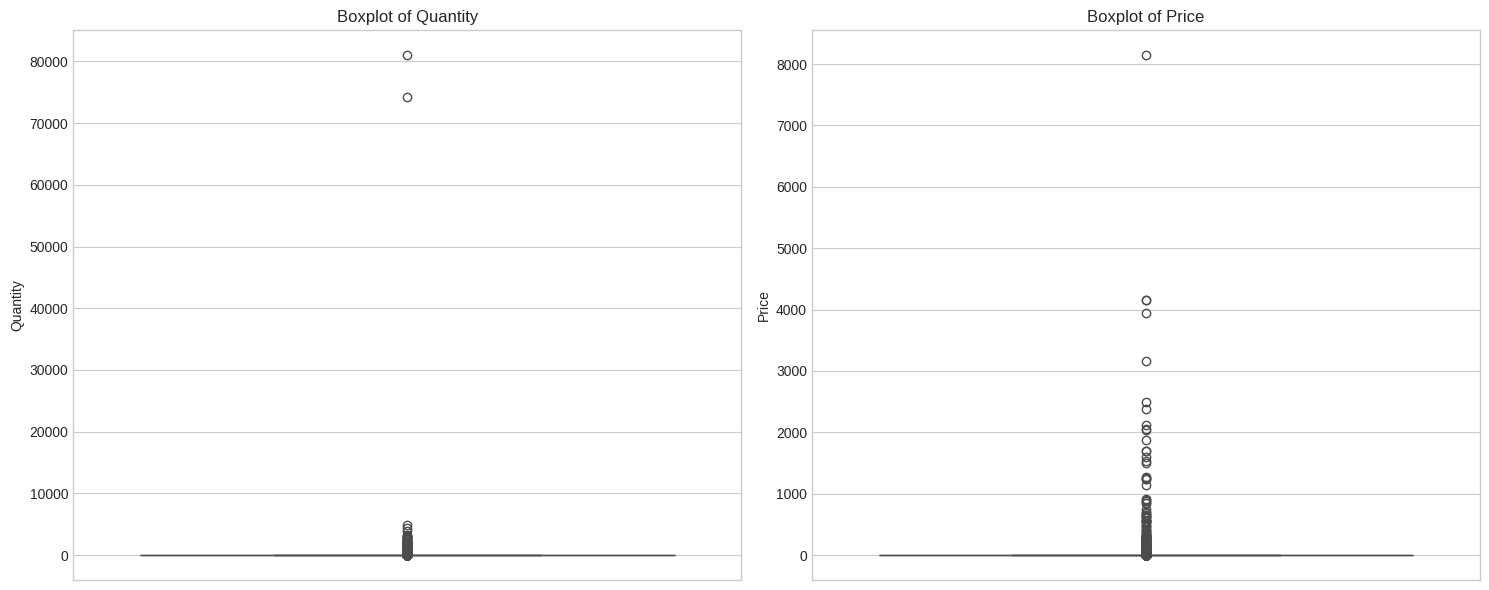

99th percentile of Quantity: 120.0
99th percentile of Price: 14.95
Records after removing outliers: 390260
Maximum date in the dataset: 2011-12-10 12:50:00


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cleaned data saved to 'data/processed/online_retail_cleaned.csv'


In [ ]:
# Check for outliers in Quantity and Price
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_cleaned['Quantity'])
plt.title('Boxplot of Quantity')
plt.ylabel('Quantity')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned['Price'])
plt.title('Boxplot of Price')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

# Set reasonable thresholds for outliers
quantity_threshold = df_cleaned['Quantity'].quantile(0.99)
price_threshold = df_cleaned['Price'].quantile(0.99)

print(f"99th percentile of Quantity: {quantity_threshold}")
print(f"99th percentile of Price: {price_threshold}")

# Filter extreme outliers
df_no_outliers = df_cleaned[
    (df_cleaned['Quantity'] <= quantity_threshold) &
    (df_cleaned['Price'] <= price_threshold)
]

print(f"Records after removing outliers: {len(df_no_outliers)}")

# Calculate the maximum date in the dataset to use for recency calculation
max_date = df_no_outliers['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Maximum date in the dataset: {max_date}")

# Save processed data
df_no_outliers.to_csv('data/processed/online_retail_cleaned.csv', index=False)
files.download('data/processed/online_retail_cleaned.csv')

print("Cleaned data saved to 'data/processed/online_retail_cleaned.csv'")


##**Creating a summary of the data cleaning process**

In [ ]:
# Create a summary of the data cleaning process
cleaning_summary = pd.DataFrame({
    'Step': ['Original data', 'After removing missing CustomerID', 'After removing cancelled orders',
             'After removing invalid prices', 'After removing outliers'],
    'Records': [len(df), len(df_with_customerid), len(df_cleaned),
               len(df_cleaned[df_cleaned['Price'] > 0]), len(df_no_outliers)]
})

print("\nData cleaning summary:")
display(cleaning_summary)

print("\nCleaned dataset sample:")
display(df_no_outliers.head())


Data cleaning summary:


,Step,Records
0,Original data,541910
1,After removing missing CustomerID,406830
2,After removing cancelled orders,397885
3,After removing invalid prices,397885
4,After removing outliers,390260



Cleaned dataset sample:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceDayOfWeek,InvoiceHour,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,2,8,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,2,8,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,2,8,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,2,8,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,2,8,20.34
